<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Neural_Network/Fashion_Classification_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Persiapan Lingkungan dan Eksplorasi Data

## Mengimpor Library Utama

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Tensorflow version:", tf.__version__)

Tensorflow version: 2.20.0


## Memuat Dataset Fashion-MNIST dan Menentukan Nama Kelas

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Memeriksa Ukuran Data dan Rentang Nilai Piksel

In [3]:
print(f"Training image shape: {x_train.shape}")
print(f"Training labels count: {len(x_train)}")
print(f"Testing image shape: {x_test.shape}")
print(f"Testing labels count: {len(x_test)}")

print(f"Min pixel value: {x_train.min()}")
print(f"Max pixel value: {x_train.max()}")

Training image shape: (60000, 28, 28)
Training labels count: 60000
Testing image shape: (10000, 28, 28)
Testing labels count: 10000
Min pixel value: 0
Max pixel value: 255


## Menampilkan Sampel Gambar Beserta Labelnya

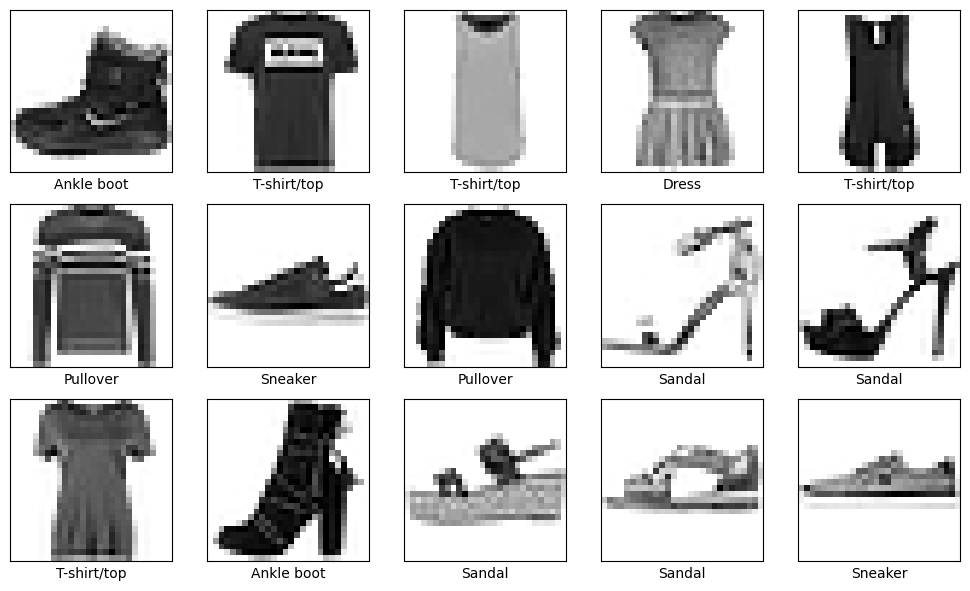

In [4]:
plt.figure(figsize=(10, 6))
for i in range(15):
  plt.subplot(3, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(x_train[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[y_train[i]])

plt.tight_layout()
plt.show()

# Fase 2: Pra-pemrosesan Data (Data Preprocessing)

## Normalisasi Nilai Piksel Gambar

In [5]:
x_train_normalized = x_train / 255.0
x_test_normalized = x_test / 255.0

print(f"Normalized min pixel value: {x_train_normalized.min()}")
print(f"Normalized max pixel value: {x_train_normalized.max()}")

Normalized min pixel value: 0.0
Normalized max pixel value: 1.0


## Menyesuaikan Bentuk Tensor (Reshaping) untuk *channel* warna

In [6]:
x_train_reshaped = x_train_normalized.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test_normalized.reshape(-1, 28, 28, 1)

print(f"Reshaped training data shape: {x_train_reshaped.shape}")
print(f"Reshaped testing data shape: {x_test_reshaped.shape}")

Reshaped training data shape: (60000, 28, 28, 1)
Reshaped testing data shape: (10000, 28, 28, 1)


## Menampilkan Ringkasan Data

In [7]:
print("--- Data Preprocessing Summary ---")
print(f"Training images final shape : {x_train_reshaped.shape}")
print(f"Testing images final shape  : {x_test_reshaped.shape}")
print(f"Data type of images         : {x_train_reshaped.dtype}")
print(f"Data type of labels         : {x_train.dtype}")

--- Data Preprocessing Summary ---
Training images final shape : (60000, 28, 28, 1)
Testing images final shape  : (10000, 28, 28, 1)
Data type of images         : float64
Data type of labels         : uint8


# Fase 3: Pembangunan Arsitektur Model CNN

## Menyusun Struktur Arsitektur CNN

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Mengompilasi Model & Menampilkan Ringkasan Arsitektur Model

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

# Fase 4: Pelatihan dan Evaluasi Model

## Melatih Model CNN (`model.fit`)

In [10]:
EPOCHS = 10
BATCH_SIZE = 64

history = model.fit(
    x_train_reshaped,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test_reshaped, y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 62ms/step - accuracy: 0.8162 - loss: 0.5065 - val_accuracy: 0.8595 - val_loss: 0.3968
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.8788 - loss: 0.3327 - val_accuracy: 0.8816 - val_loss: 0.3261
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 67ms/step - accuracy: 0.8962 - loss: 0.2868 - val_accuracy: 0.8915 - val_loss: 0.2975
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.9052 - loss: 0.2581 - val_accuracy: 0.8873 - val_loss: 0.3025
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 56s 59ms/step - accuracy: 0.9128 - loss: 0.2378 - val_accuracy: 0.9055 - val_loss: 0.2673
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 55ms/step - accuracy: 0.9200 - loss: 0.2188 - val_accuracy: 0.8991 - val_loss: 0.2741
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 54ms/step - accuracy: 0.9275 - loss: 0.1981 - val_accuracy: 0.9060 - val_loss: 0.2535
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.9313 - loss: 0.1857 - 

## Evaluasi Akhir Performa Model (`model.evaluate`)

In [11]:
test_loss, test_accuracy = model.evaluate(x_test_reshaped, y_test, verbose=0)

print(f"Final Test Loss      : {test_loss:.4f}")
print(f"Final Test Accuracy : {test_accuracy * 100:.2f}")

Final Test Loss      : 0.2469
Final Test Accuracy : 91.28


## Visualisasi Grafik Perkembangan Akurasi dan Loss

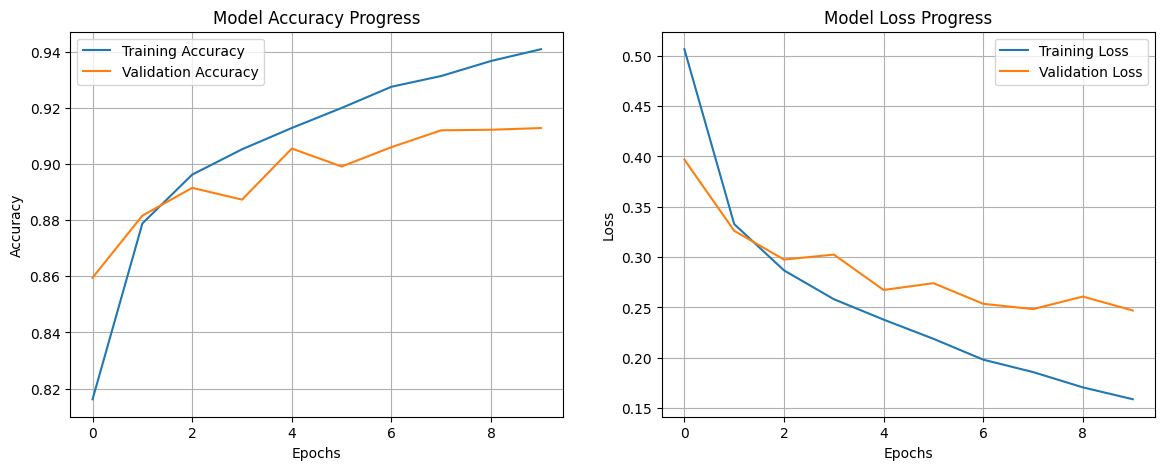

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"], label="Training Accuracy")
ax1.plot(history.history["val_accuracy"], label="Validation Accuracy")
ax1.set_title("Model Accuracy Progress")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2.plot(history.history["loss"], label="Training Loss")
ax2.plot(history.history["val_loss"], label="Validation Loss")
ax2.set_title("Model Loss Progress")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.show()